<a href="https://colab.research.google.com/github/SalgadoHUB/Classical_Mechanics_II/blob/main/Tareas/Tarea2_Inercia_Crookes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Matriz de inercia de un radiómetro de Crookes

Nuestro radiómetro (molinillo de luz) consiste en cuatro aspas de mica, unidas por alambres ideales (sin masa), que pueden pivotar en torno a un punto de apoyo. Idealmente, el molino gira en tornoa un eje vertical, como se muestra en la siguiente figura:

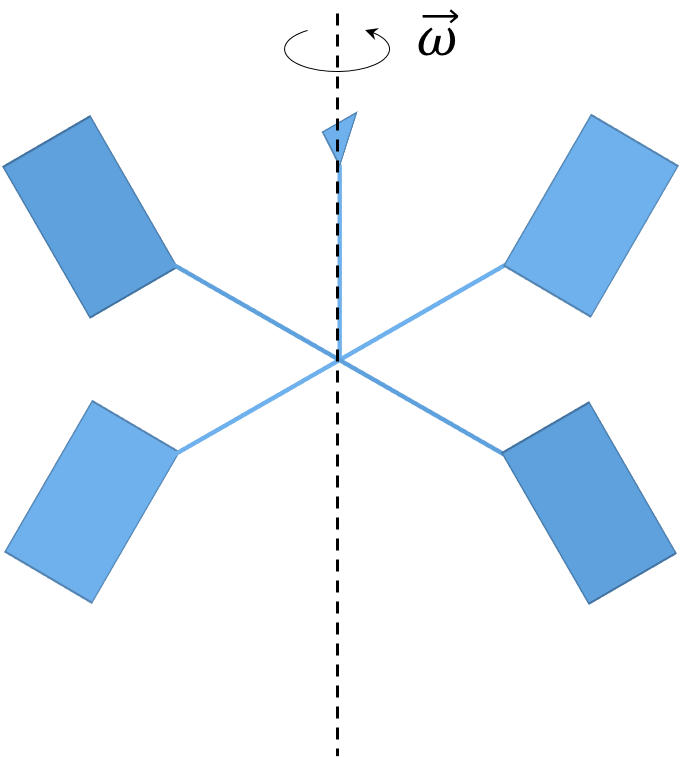


Comenzamos calculando los momentos de inercia de cada placa de mica respecto a sus centros de masas, y luego aplicaremos Steiner para trasladar los momentos de inercia al punto de apoyo.

## Momento de inercia de placa rectangular

Cada placa tiene lado $L$ y espesor despreciable. Como ejes principales tomamos dos direcciones en las diagonales (una horizontal, otra vertical) y la dirección perpendicular a cada placa. El eje vertical será $e_3$, los otros dos dependerán de la orientación de las placas.

## - Diagonal vertical

Tomamos elementos longitudinales situados a distancia $x$ del eje, de espesor $dx$, y longitud $h$. Esta longitud está limitada por los bordes rectos de la placa. Por la derecha, la ecuación de la recta que define el borde superior es:

\begin{equation}
y_d = \frac{L}{\sqrt{2}} - x.
\end{equation}

Podemos calcular la longitud del elemento diferencial como $h_d=2y$. Por el lado de la izquierda, el borde superior sigue la ecuación,

\begin{equation}
y_i = \frac{L}{\sqrt{2}} + x.
\end{equation}

Y similarmente calculamos su altura como $h_d=2y$. Así que el momento de inercia se puede calcular como:

\begin{equation}
I_3 = \int_{-\frac{L}{\sqrt{2}}}^{0} \sigma x^2 h_i \, dx + \int_{0}^{\frac{L}{\sqrt{2}}} \sigma x^2h_d \, dx = \int_{-\frac{L}{\sqrt{2}}}^{0} \sigma x^2 2(\frac{L}{\sqrt{2}} + x) \, dx + \int_{0}^{\frac{L}{\sqrt{2}}} \sigma x^2 2(\frac{L}{\sqrt{2}} - x) \, dx.
\end{equation}

Hacemos ahora las cuentas en SymPy.

In [ ]:
import sympy as smp
from sympy import latex # para mostrar los resultados
from IPython.display import Math # para mostrar los resultados

In [ ]:
x, y, z = smp.symbols('x y z') # cartesianas

M, L, sigma = smp.symbols('M L sigma') # Masa, lado y densidad superficial de la placa cuadrada.
h, d = smp.symbols('h, d') #dimensiones del molino

In [ ]:
D = M/L**2

Iv_cdm = smp.integrate(D*(x**2)*2*((L/smp.sqrt(2) + x)), (x, -L/smp.sqrt(2), 0)) + smp.integrate(D*(x**2)*2*((L/smp.sqrt(2) - x)), (x, 0, L/smp.sqrt(2)))
Iv_cdm

L**2*M/12

### Diagonal horizontal

Lo llamamos, por ejemplo, $I_h$ en esta dirección. Por simetría, $I_h$ = $I_v$.

In [ ]:
Ih_cdm = Iv_cdm

### Dirección perpendicular

Lo llamamos, de momento $I_p$. Como es un cuerpo plano, $I_p = I_h + I_v$.

In [ ]:
Ip_cdm = Ih_cdm + Iv_cdm

### Matriz de inercia $I^*$ para cada placa

Construímos la matriz, teniendo en cuenta que para cada placa habrá que orientar los ejes $I_1$ e $I_2$ correctamente. Numeramos nuestras placas como A, B, C y D, y tenemos:

In [ ]:
IA_cdm = smp.Matrix([[Ip_cdm, 0, 0], [0, Ih_cdm, 0], [0, 0, Iv_cdm]])
IA_cdm

Matrix([
[L**2*M/6,         0,         0],
[       0, L**2*M/12,         0],
[       0,         0, L**2*M/12]])

In [ ]:
IB_cdm = smp.Matrix([[Ih_cdm, 0, 0], [0, Ip_cdm, 0], [0, 0, Iv_cdm]])
IB_cdm

Matrix([
[L**2*M/12,        0,         0],
[        0, L**2*M/6,         0],
[        0,        0, L**2*M/12]])

In [ ]:
IC_cdm = smp.Matrix([[Ip_cdm, 0, 0], [0, Ih_cdm, 0], [0, 0, Iv_cdm]])
IC_cdm

Matrix([
[L**2*M/6,         0,         0],
[       0, L**2*M/12,         0],
[       0,         0, L**2*M/12]])

In [ ]:
ID_cdm = smp.Matrix([[Ih_cdm, 0, 0], [0, Ip_cdm, 0], [0, 0, Iv_cdm]])
ID_cdm

Matrix([
[L**2*M/12,        0,         0],
[        0, L**2*M/6,         0],
[        0,        0, L**2*M/12]])

Nótese que $I_3$ es igual para todas las matrices. Si el movimiento se da con su velocidad angular contenida exclusivamente en el eje $e_3$, ésta sería la única dirección que nos importaría.

## Steiner

Trasladamos los momentos de cada placa al punto de apoyo, utilizando Steiner:

$\vec{\mathbb{I}}_O = \vec{\mathbb{I}}_R + \vec{\mathbb{I}}^*$

Para calcular \vec{\mathbb{I}}_R necesitamos la posición del centro de masas desde $O$, que habrá que calcularlo para cada placa.

In [ ]:
R_A = smp.Matrix([0, d, h])
R_B = smp.Matrix([-d, 0, h])
R_C = smp.Matrix([0, -d, h])
R_D = smp.Matrix([d, 0, h])

IR_A = M * smp.Matrix([[R_A[1]**2 + R_A[2]**2, -R_A[0]*R_A[1], -R_A[0]*R_A[2]], [-R_A[1]*R_A[0], R_A[0]**2 + R_A[2]**2, -R_A[1]*R_A[2]], [-R_A[2]*R_A[0], -R_A[2]*R_A[1], R_A[0]**2 + R_A[1]**2]])
IR_B = M * smp.Matrix([[R_B[1]**2 + R_B[2]**2, -R_B[0]*R_B[1], -R_B[0]*R_B[2]], [-R_B[1]*R_B[0], R_B[0]**2 + R_B[2]**2, -R_B[1]*R_B[2]], [-R_B[2]*R_B[0], -R_B[2]*R_B[1], R_B[0]**2 + R_B[1]**2]])
IR_C = M * smp.Matrix([[R_C[1]**2 + R_C[2]**2, -R_C[0]*R_C[1], -R_C[0]*R_C[2]], [-R_C[1]*R_C[0], R_C[0]**2 + R_C[2]**2, -R_C[1]*R_C[2]], [-R_C[2]*R_C[0], -R_C[2]*R_C[1], R_C[0]**2 + R_C[1]**2]])
IR_D = M * smp.Matrix([[R_D[1]**2 + R_D[2]**2, -R_D[0]*R_D[1], -R_D[0]*R_D[2]], [-R_D[1]*R_D[0], R_D[0]**2 + R_D[2]**2, -R_D[1]*R_D[2]], [-R_D[2]*R_D[0], -R_D[2]*R_D[1], R_D[0]**2 + R_D[1]**2]])

IO_A = IR_A + IA_cdm
IO_B = IR_B + IB_cdm
IO_C = IR_C + IC_cdm
IO_D = IR_D + ID_cdm

IO = IO_A + IO_B + IO_C + IO_D
display(Math(r" \mathbf{I_O} = " + smp.latex(IO)))

<IPython.core.display.Math object>

## b) Sustituimos las dimensiones del cuerpo

- $𝐿 = 16$ mm
- $𝑑 = 15$ mm
- $ℎ = 5$ mm
- $𝜎 = 2.8 g/cm^2$

In [ ]:


# Sustituimos los valores numéricos
masa = 28*(16e-3)**2 # en kg
valores = {L: 16e-3, d: 15e-3, h: 5e-3, M: masa}  # en kg y metros

IO_real = IO.subs(valores)
display(Math(r" \mathbf{I_O} = " + smp.latex(IO_real) + "kg·m^2"))

<IPython.core.display.Math object>